<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fpmahlin/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [2]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_193/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_193/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


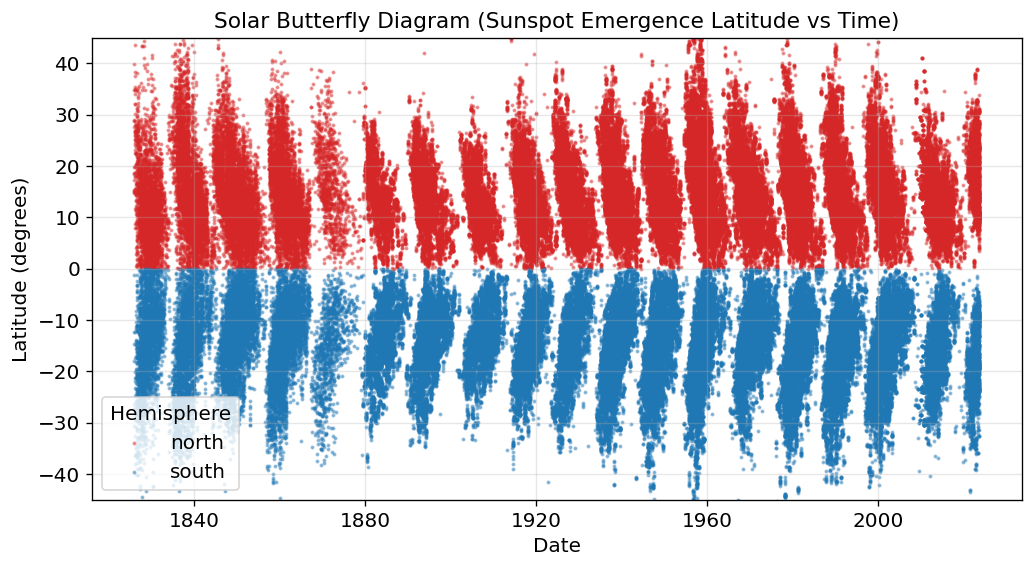

In [4]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


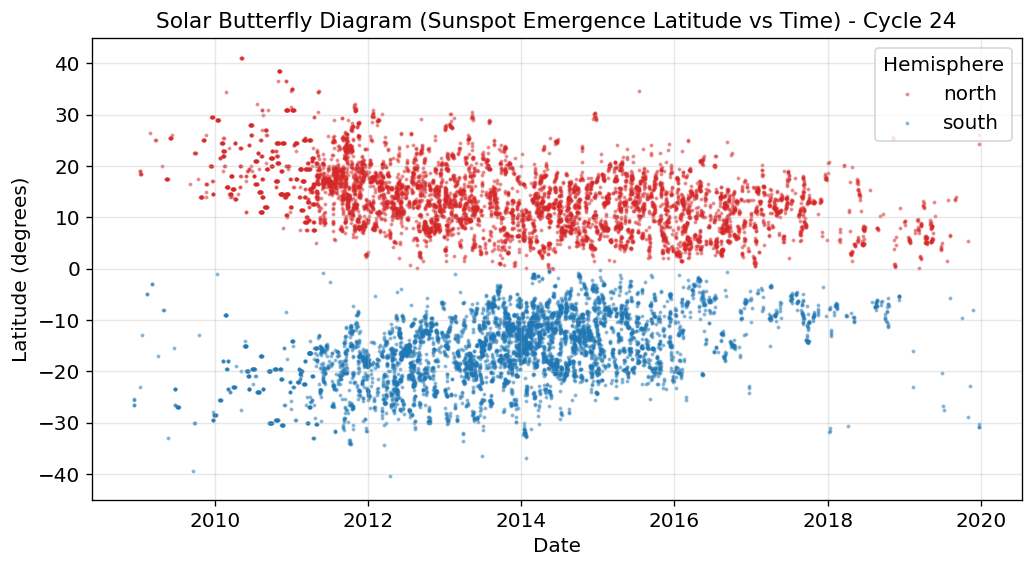

In [5]:
# Your code here: Visualize a single solar cycle

# Cycle 24 range
start_date = '2008-12-01'
end_date = '2019-12-31'

# Filtering the data
df_cycle24 = df[(df['date'] >= start_date) & (df['date'] <= end_date)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle24.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time) - Cycle 24")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_193/569522737.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mean_latitude_monthly = df_indexed.groupby('hemisphere').resample('M')['latitude'].mean().reset_index()


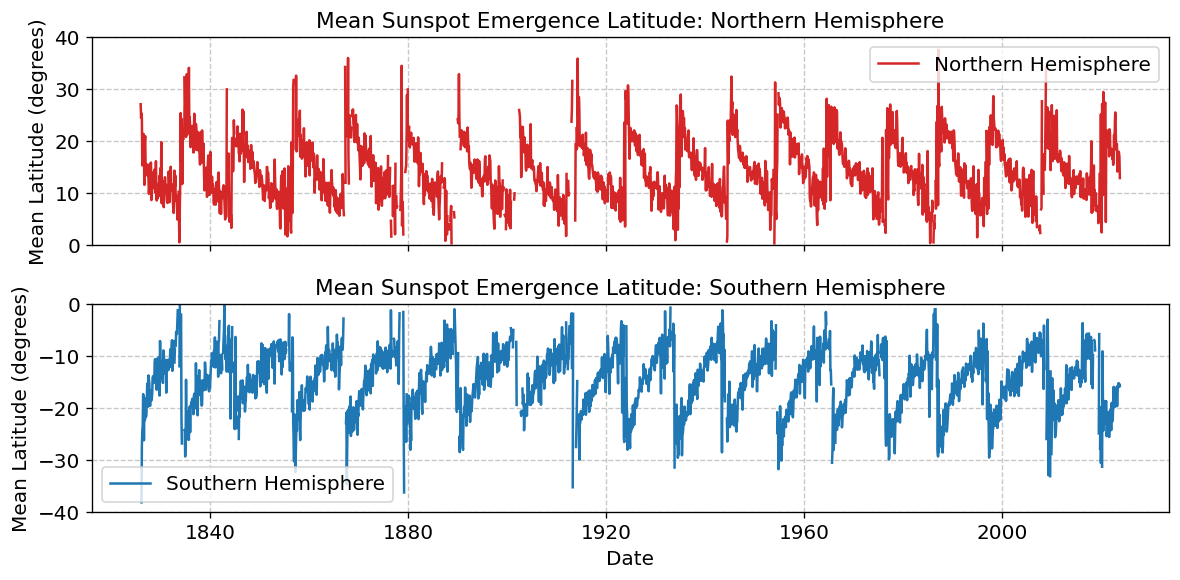

In [11]:
# Your code here: Calculate and plot mean latitudinal paths

# Ensure 'date' is a datetime object and set as index for resampling
df_indexed = df.set_index('date')

# Group by hemisphere and resample by month, then calculate the mean latitude
mean_latitude_monthly = df_indexed.groupby('hemisphere').resample('M')['latitude'].mean().reset_index()

north_mean_latitude = mean_latitude_monthly[mean_latitude_monthly['hemisphere'] == 'north']
south_mean_latitude = mean_latitude_monthly[mean_latitude_monthly['hemisphere'] == 'south']

# Plotting the mean latitudinal paths
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Plot for Northern Hemisphere
ax1.plot(north_mean_latitude['date'], north_mean_latitude['latitude'], color='tab:red', label='Northern Hemisphere')
ax1.set_title('Mean Sunspot Emergence Latitude: Northern Hemisphere')
ax1.set_ylabel('Mean Latitude (degrees)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(0, 40)

# Plot for Southern Hemisphere
ax2.plot(south_mean_latitude['date'], south_mean_latitude['latitude'], color='tab:blue', label='Southern Hemisphere')
ax2.set_title('Mean Sunspot Emergence Latitude: Southern Hemisphere')
ax2.set_xlabel('Date')
ax2.set_ylabel('Mean Latitude (degrees)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_ylim(-40, 0)

plt.tight_layout()
plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Response:*

That's a great question! To effectively learn machine learning and solar physics concepts with an AI assistant, it's crucial to formulate your prompts carefully. Here's a plan outlining some best practices:

**Understand Your Goal:** Before prompting, clearly define what you want to learn (e.g., 'Explain the math behind neural networks', 'How does magnetic reconnection cause solar flares?').

**Be Specific and Provide Context:** Avoid vague questions. Specify the level of detail, target audience (e.g., 'Explain to a beginner', 'Explain like I'm 5', 'Provide a university-level explanation'), and any prior knowledge you have. For solar physics, mention the specific phenomena or terms. For ML, specify algorithms or concepts.

**Ask for Explanations and Analogies:** Request clear, concise explanations. Ask for analogies or real-world examples to help solidify abstract concepts. For ML, ask for code examples if applicable.

**Request Step-by-Step Breakdowns:** For complex topics, ask the AI to break down the explanation into smaller, digestible steps. This helps in building foundational understanding.
Ask for Comparisons and Contrasts: To deepen understanding, ask the AI to compare and contrast related concepts (e.g., 'What's the difference between supervised and unsupervised learning?', 'How do CMEs differ from solar flares?').

**Prompt for Practical Applications:** Ask how the concepts are applied in real-world scenarios, both in machine learning and solar physics. This helps connect theory to practice.
Iterate and Refine: Don't be afraid to ask follow-up questions. If an explanation isn't clear, ask for clarification or a different perspective. Provide feedback to the AI on what worked and what didn't.

**Request Learning Resources:** Ask the AI to recommend reputable books, papers, courses, or online resources for further self-study on the topic.

**Final Task:** Summarize the key takeaways from the AI's advice on effective prompting for learning machine learning and solar physics.

*Your reflection here:*


I will be precise with the information I want to gain, e.g., upper-level explanations. I want coding examples and multiple variations for how it can be done. I will ask for step-by-step explanations for the code, to understand each part, so I can rely less on AI in the future and code from memory. I will ask for real world applications/examples/explanations for ML concepts and algorithms.